In [42]:
import numpy as np
from math import sqrt
from sklearn import datasets, linear_model, metrics
from pprint import pprint
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate, train_test_split, KFold
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectPercentile, f_regression
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Carga de datos.
dataset = datasets.fetch_california_housing()
X = dataset.data
y = dataset.target
print(np.shape(X))

(20640, 8)


In [3]:
# Métricas de evaluación.
metricas = {'MAE':  'neg_mean_absolute_error',
            'RMSE': make_scorer(lambda y, y_pred:
                      sqrt(metrics.mean_squared_error(y, y_pred)),
                      greater_is_better=False),
            'MAPE': make_scorer(lambda y, y_pred:
                      np.mean(np.abs((y - y_pred) / y)) * 100,
                      greater_is_better=False)}

### 1) PARTICIÓN EXTERNA DE DATOS

In [4]:
# 1) Partición de datos externa
X_training, X_testing, y_training, y_testing = train_test_split(X, y, test_size=0.2, random_state=42)
print(np.shape(X_training))
print(np.shape(X_testing))

(16512, 8)
(4128, 8)


### 2-5) ENTRENAMIENTO

In [5]:
# 2) Extracción de características, ESTA PARTE NO LA HICIMOS EN CLASE PERO SE DEBERÍA HACER
# 3) Selección de atributos

In [6]:
# 4) Estandarización de los datos de entrenamiento
standardizer = preprocessing.StandardScaler()
X_stdr = standardizer.fit_transform(X_training)

In [19]:
# 5) Construcción del algoritmo de aprendizaje.
k = 15
reg2 = KNeighborsRegressor(n_neighbors = k, weights='distance', metric='euclidean')
reg = RadiusNeighborsRegressor(radius = 1.0, weights='distance', metric='euclidean')

In [18]:
# 5.1) Validación cruzada interna ( Radius)

# Extraer MEAN +- STD del coeficiente de determinación (R2) para un cross validation de 5 bolsas aleatorias y semilla en 42
r2_cv_results = cross_val_score(reg, X_stdr, y_training, cv=KFold(n_splits =5, shuffle=True, random_state=42))
print("cross_val_R2:   %0.4f +/- %0.4f" % (r2_cv_results.mean(), r2_cv_results.std()))
#y_training ES LA VARIABLE OBJETIVO
# CON LA k= 5 NOS DA EL VALOR cross_val_R2:   0.6962 +/- 0.0096, PERO PODEMOS PROBAR A BAJAR EL VALOR DE K=5 A VER SI MEJORA EL VALOR
#LO MEJOR ES HACER UN BUCLE CON DISTINTOS VALORES A VER CON CUAL FUNCIONA MEJOR

cross_val_R2:   nan +/- nan


In [20]:
# 5.1) Validación cruzada interna (K- vecinos)

# Extraer MEAN +- STD del coeficiente de determinación (R2) para un cross validation de 5 bolsas aleatorias y semilla en 42
r2_cv_results = cross_val_score(reg2, X_stdr, y_training, cv=KFold(n_splits =5, shuffle=True, random_state=42))
print("cross_val_R2:   %0.4f +/- %0.4f" % (r2_cv_results.mean(), r2_cv_results.std()))
#y_training ES LA VARIABLE OBJETIVO
# CON LA k= 5 NOS DA EL VALOR cross_val_R2:   0.6962 +/- 0.0096, PERO PODEMOS PROBAR A BAJAR EL VALOR DE K=5 A VER SI MEJORA EL VALOR
#LO MEJOR ES HACER UN BUCLE CON DISTINTOS VALORES A VER CON CUAL FUNCIONA MEJOR

cross_val_R2:   0.6941 +/- 0.0109


In [21]:
# Extraer métricas MAE, MSE, RMSE y MAPE en un cross validation para 5 bolsas aleatorias y semilla en 42
metrics_cv_results = cross_validate(reg2, X_stdr, y_training, cv=KFold(n_splits =5, shuffle=True, random_state=42), scoring=metricas)
pprint(metrics_cv_results)

{'fit_time': array([0.02593303, 0.01700425, 0.01348853, 0.01335359, 0.01775742]),
 'score_time': array([0.26780438, 0.23455071, 0.25489926, 0.28640652, 0.23336053]),
 'test_MAE': array([-0.45745043, -0.44007316, -0.42755131, -0.44482528, -0.43900852]),
 'test_MAPE': array([-24.87035095, -24.26596667, -24.14499846, -24.71463005,
       -23.93890133]),
 'test_RMSE': array([-0.65544071, -0.637513  , -0.61708203, -0.65401477, -0.63262614])}


In [22]:
# Extraer las predicciones del cross validation de 5 bolsas aleatorias y semilla en 42
y_pred = cross_val_predict(reg2, X_stdr, y_training, cv=KFold(n_splits =5, shuffle=True, random_state=42))

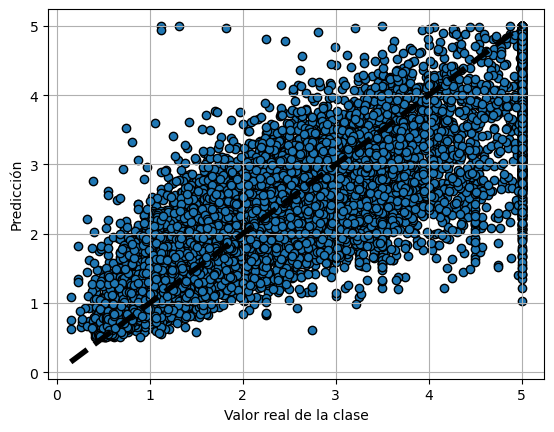

In [23]:
# Crear una función que dadas las variables "y" e "y_pred" se visualice la bisectriz
def plot_bisectriz(y, y_pred):
    fig, ax = plt.subplots()
    ax.scatter(y, y_pred, edgecolors=(0, 0, 0))
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
    ax.set_xlabel('Valor real de la clase')
    ax.set_ylabel('Predicción')
    plt.grid()
    plt.show()

# Visualiza la bisetriz
plot_bisectriz(y_training, y_pred)

In [34]:
# 5.2) Entrenamiento del modelo definitivo
model = reg2.fit(X_stdr, y_training)

### 6-10) PREDICCIÓN

In [35]:
# 6) Extracción de las características de test
# 7) Selección de los atributos de test 

In [36]:
# 8) Estandarización de las característiacs de test
X_test_stdr = standardizer.transform(X_testing)

In [37]:
# 9) Predicción del conjunto de test
y_pred_test = model.predict(X_test_stdr)

MAE:  0.4352
MSE: 0.4129
RMSE: 0.6426
R2:   0.6849


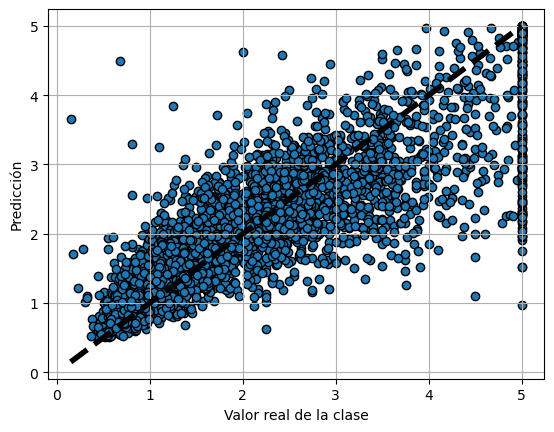

In [38]:
# 10) Evaluación del modelo sobre el conjunto de test
# MAE = metrics.mean_absolute_error(y_testing, y_pred_test)
# MSE = metrics.mean_squared_error(y_testing, y_pred_test, squared=True)
# RMSE = metrics.mean_squared_error(y_testing, y_pred_test, squared=False)
# R2 = metrics.r2_score(y_testing, y_pred_test)
MAE = metrics.mean_absolute_error(y_testing, y_pred_test)
MSE = metrics.mean_squared_error(y_testing, y_pred_test)
RMSE = metrics.root_mean_squared_error(y_testing, y_pred_test)
MAPE = metrics.mean_absolute_percentage_error(y_testing, y_pred_test)
R2 = metrics.r2_score(y_testing, y_pred_test)

print('MAE:  %.4f' % MAE)
print('MSE: %.4f' % MSE)
print('RMSE: %.4f' % RMSE)
print('R2:   %.4f' % R2)

# Visualización de resultados
plot_bisectriz(y_testing, y_pred_test)
#con este en comparacion al del PROG 12 estamos obteniendo mejores resultados
#ahora temeos mas puntos outliers
#el error ya no es constante con respecto a todos los valores de y

### ACTIVIDAD EXTRA

#### Entrenar el mejor modelo posible con el algoritmo KNN y comparar el resultado con el modelo OLS en test

In [39]:
from sklearn.model_selection import GridSearchCV
# Definir parámetros de búsqueda
# Probamos diferentes valores de K y formas de ponderar la distancia
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
# Aplicar el algoritmo de búsqueda
# Usamos el regresor KNN y validación cruzada de 5 pliegues
grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring='r2')

# Entrenar el modelo de datos estandarizados
grid_search.fit(X_stdr, y_training)

# Extraer los mejores parámetros
print("Mejores parámetros encontrados:", grid_search.best_params_)
best_knn = grid_search.best_estimator_

Mejores parámetros encontrados: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}



--- Resultados en Test ---
KNN - R2: 0.7221
KNN - MAE: 0.4058
OLS - R2: 0.5758
OLS - MAE: 0.5332


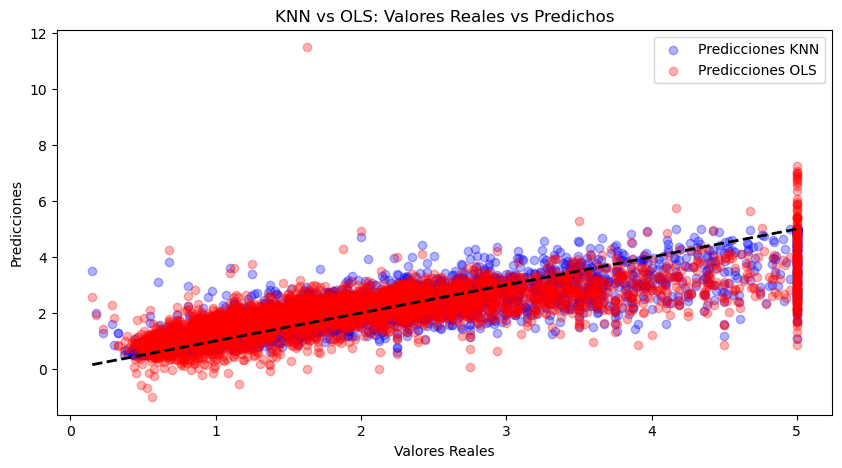

In [43]:
# Entrenar cada algoritmo y comparar los resultados (a nivel cuantitativo y cualitativo) sobre el conjunto de test
# Preparar datos de test (usando el mismo escalador del entrenamiento)
X_test_stdr = standardizer.transform(X_testing)

# Entrenar modelo OLS (Regresión Lineal)
ols_model = LinearRegression()
ols_model.fit(X_stdr, y_training)

# Predicciones
y_pred_knn = best_knn.predict(X_test_stdr)
y_pred_ols = ols_model.predict(X_test_stdr)

# Métricas Cuantitativas
print("\n--- Resultados en Test ---")
print(f"KNN - R2: {metrics.r2_score(y_testing, y_pred_knn):.4f}")
print(f"KNN - MAE: {metrics.mean_absolute_error(y_testing, y_pred_knn):.4f}")

print(f"OLS - R2: {metrics.r2_score(y_testing, y_pred_ols):.4f}")
print(f"OLS - MAE: {metrics.mean_absolute_error(y_testing, y_pred_ols):.4f}")

# Comparación Cualitativa (Gráfico)
plt.figure(figsize=(10, 5))
plt.scatter(y_testing, y_pred_knn, alpha=0.3, label='Predicciones KNN', color='blue')
plt.scatter(y_testing, y_pred_ols, alpha=0.3, label='Predicciones OLS', color='red')
plt.plot([y_testing.min(), y_testing.max()], [y_testing.min(), y_testing.max()], 'k--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('KNN vs OLS: Valores Reales vs Predichos')
plt.legend()
plt.show()